In [1]:
# ENSEMBLE XAUUSD – 3EMA + MACD

import pandas as pd
import numpy as np
from pathlib import Path
import json
import yfinance as yf
import vectorbt as vbt


# ============================================================
# 1) LOAD DATA
# ============================================================

# DOWNLOAD STOCK DATA FROM 2018 USING YFINANCE

# Configuration - Change these variables as needed
TICKER = 'GC=F'  # Any ticker symbol (e.g., 'AAPL', 'MSFT', 'GOOGL')
START_DATE = '2018-01-01'  # Any start date in YYYY-MM-DD format

# Download data from start date onwards
stock_data = yf.download(TICKER, start=START_DATE, interval='1d')

if not stock_data.empty:
    print(f"Successfully downloaded {len(stock_data)} records for {TICKER} from {START_DATE}")
    print(f"Data range: {stock_data.index.min().date()} to {stock_data.index.max().date()}")
    print("\nFirst 5 rows:")
    print(stock_data.head())
else:
    print(f"Failed to download {TICKER} data from yfinance")

# Display the downloaded data
stock_data



C:\Users\clanf\AppData\Local\Temp\ipykernel_22620\2565152039.py:22: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Successfully downloaded 2003 records for GC=F from 2018-01-01
Data range: 2018-01-02 to 2025-12-17

First 5 rows:
Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2018-01-02  1313.699951  1317.599976  1302.300049  1302.300049     68
2018-01-03  1316.199951  1320.099976  1312.099976  1320.000000     42
2018-01-04  1319.400024  1322.000000  1319.400024  1319.400024      2
2018-01-05  1320.300049  1320.300049  1320.300049  1320.300049      1
2018-01-08  1318.599976  1319.900024  1314.599976  1319.900024     41


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2018-01-02,1313.699951,1317.599976,1302.300049,1302.300049,68
2018-01-03,1316.199951,1320.099976,1312.099976,1320.000000,42
2018-01-04,1319.400024,1322.000000,1319.400024,1319.400024,2
2018-01-05,1320.300049,1320.300049,1320.300049,1320.300049,1
2018-01-08,1318.599976,1319.900024,1314.599976,1319.900024,41
...,...,...,...,...,...
2025-12-11,4285.500000,4286.899902,4214.299805,4224.000000,528
2025-12-12,4300.100098,4355.000000,4260.000000,4276.399902,1531


In [ ]:
# # ============================================================
# # 2) LOAD BEST SINGLE-INDICATOR PARAMETERS (FROM JSON FILES)
# # ============================================================

# base_single = Path("data") / "single_indicator" / "xauusd"

# params_3ema_path  = base_single / "best_params_3ema_xauusd.json"
# params_macd_path  = base_single / "best_params_macd_xauusd.json"

# with params_3ema_path.open("r") as f:
#     best_3ema_xauusd = json.load(f)

# with params_macd_path.open("r") as f:
#     best_macd_xauusd = json.load(f)

# print("Best 3EMA XAUUSD params:", best_3ema_xauusd)
# print("Best MACD XAUUSD params:", best_macd_xauusd)


Best 3EMA XAUUSD params: {'ema1_period': 12, 'ema2_period': 154, 'ema3_period': 122}
Best MACD XAUUSD params: {'fast_period': 45, 'slow_period': 64, 'signal_period': 67}


In [2]:
# ============================================================
# LOAD FIXED PARAMETERS (MENTOR PARAMS)
# ============================================================

best_3ema_xauusd = {
    "ema1_period": 6,
    "ema2_period": 181,
    "ema3_period": 85
}

best_macd_xauusd = {
    "fast_period": 48,
    "slow_period": 59,
    "signal_period": 50
}

print("Loaded mentor 3EMA params:", best_3ema_xauusd)
print("Loaded mentor MACD params:", best_macd_xauusd)


Loaded mentor 3EMA params: {'ema1_period': 6, 'ema2_period': 181, 'ema3_period': 85}
Loaded mentor MACD params: {'fast_period': 48, 'slow_period': 59, 'signal_period': 50}


In [3]:
# ============================================================
# 3) STRATEGY FUNCTIONS (3EMA + MACD) with 1 / 0 / -1 signals
# ============================================================

def generate_3ema_signals(price, ema1_period, ema2_period, ema3_period):
    """
    Triple EMA crossover signals on 'price':
    +1 = entry long
    -1 = exit
     0 = neutral
    """
    # EMAs con vectorbt (come nel template)
    ema1 = vbt.MA.run(price, ema1_period, ewm=True).ma
    ema2 = vbt.MA.run(price, ema2_period, ewm=True).ma
    ema3 = vbt.MA.run(price, ema3_period, ewm=True).ma

    # Logica triple EMA (coerente col template)
    entries_raw = (
        ema1.vbt.crossed_above(ema2) |
        ema1.vbt.crossed_above(ema3) |
        ema2.vbt.crossed_above(ema3)
    )

    exits_raw = (
        ema1.vbt.crossed_below(ema2) |
        ema1.vbt.crossed_below(ema3) |
        ema2.vbt.crossed_below(ema3)
    )

    # Aggiusto index e NaN
    entries_raw = entries_raw.reindex(price.index).fillna(False)
    exits_raw = exits_raw.reindex(price.index).fillna(False)

    # ⚠️ niente look-ahead: shift di 1
    entries = entries_raw.shift(1).fillna(False).astype(bool)
    exits = exits_raw.shift(1).fillna(False).astype(bool)

    # Converto in 1 / 0 / -1
    signal = pd.Series(0, index=price.index)
    signal[entries] = 1
    signal[exits] = -1

    return signal


def generate_macd_signals(price, fast_period, slow_period, signal_period):
    """
    MACD crossover signals on 'price':
    +1 = entry long (MACD cross sopra signal)
    -1 = exit       (MACD cross sotto signal)
     0 = neutral
    """
    # MACD lines costruiti via EMA, in linea con il template
    macd_fast = vbt.MA.run(price, fast_period, ewm=True).ma
    macd_slow = vbt.MA.run(price, slow_period, ewm=True).ma
    macd = macd_fast - macd_slow
    macd_signal = vbt.MA.run(macd, signal_period, ewm=True).ma

    cross_up = (macd > macd_signal) & (macd.shift(1) <= macd_signal.shift(1))
    cross_down = (macd < macd_signal) & (macd.shift(1) >= macd_signal.shift(1))

    cross_up = cross_up.reindex(price.index).fillna(False)
    cross_down = cross_down.reindex(price.index).fillna(False)

    # ⚠️ niente look-ahead
    entries = cross_up.shift(1).fillna(False).astype(bool)
    exits = cross_down.shift(1).fillna(False).astype(bool)

    signal = pd.Series(0, index=price.index)
    signal[entries] = 1
    signal[exits] = -1

    return signal


In [4]:
# ============================================================
# 3.5) LOAD DATA INTO df (same structure as Template-3EMA and MACD)
# ============================================================


# Parameters (ensure consistency with the single-indicator notebooks)
TICKER = "GC=F"
START_DATE = "2018-01-01"
END_DATE = None  # latest

print(f"Downloading data for {TICKER}...")
stock_data = yf.download(TICKER, start=START_DATE, end=END_DATE)

if stock_data.empty:
    raise ValueError("Downloaded data is empty. Check TICKER or internet connection.")

# Create df following the exact style of the 3EMA notebook
df = stock_data.copy()

# Use close price (as in the 3EMA template)
df["close"] = df["Close"]

# Optional: return columns if used elsewhere
df["returns"] = df["close"].pct_change().fillna(0)

# Clean dataframe
df = df.dropna().copy()

print("Data loaded into df → shape:", df.shape)
df.head()


C:\Users\clanf\AppData\Local\Temp\ipykernel_22620\3922635212.py:12: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Data loaded into df → shape: (2003, 7)


Price,Close,High,Low,Open,Volume,close,returns
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,,
Date,,,,,,,
2018-01-02,1313.699951,1317.599976,1302.300049,1302.300049,68,1313.699951,0.000000
2018-01-03,1316.199951,1320.099976,1312.099976,1320.000000,42,1316.199951,0.001903
2018-01-04,1319.400024,1322.000000,1319.400024,1319.400024,2,1319.400024,0.002431
2018-01-05,1320.300049,1320.300049,1320.300049,1320.300049,1,1320.300049,0.000682
2018-01-08,1318.599976,1319.900024,1314.599976,1319.900024,41,1318.599976,-0.001288


In [5]:
# ============================================================
# 4) REBUILD SINGLE-INDICATOR SIGNALS USING BEST PARAMS
# ============================================================

# Assumo che df esista già e che contenga almeno la colonna 'close'
if "df" not in globals():
    raise ValueError("DataFrame 'df' not found. Make sure you loaded your data into df first.")

if "close" not in df.columns:
    raise ValueError("Column 'close' not found in df. Make sure df has a 'close' price column.")

price = df["close"].copy()

signal_3ema = generate_3ema_signals(
    price=price,
    ema1_period=best_3ema_xauusd["ema1_period"],
    ema2_period=best_3ema_xauusd["ema2_period"],
    ema3_period=best_3ema_xauusd["ema3_period"],
)

signal_macd = generate_macd_signals(
    price=price,
    fast_period=best_macd_xauusd["fast_period"],
    slow_period=best_macd_xauusd["slow_period"],
    signal_period=best_macd_xauusd["signal_period"],
)

signals_df = pd.DataFrame({
    "price": price,
    "signal_3ema": signal_3ema,
    "signal_macd": signal_macd,
})

signals_df.head()


C:\Users\clanf\AppData\Local\Temp\ipykernel_22620\2931417336.py:35: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\clanf\AppData\Local\Temp\ipykernel_22620\2931417336.py:36: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\clanf\AppData\Local\Temp\ipykernel_22620\2931417336.py:66: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

,price,signal_3ema,signal_macd
Date,,,
2018-01-02,1313.699951,0,0
2018-01-03,1316.199951,0,0
2018-01-04,1319.400024,0,0
2018-01-05,1320.300049,0,0
2018-01-08,1318.599976,0,0


In [6]:
def build_ensemble_position(signal_3ema, signal_macd, initial_position=0):
    """
    Ensemble 3EMA (s1) + MACD (s2) con logica:

    ENTRY (quando flat):
      - entra long se:
            s1 == 1
        oppure:
            s2 == 1 e s1 != -1    → MACD può anticipare se 3EMA non è short
      - NON entra se:
            s1 == -1              → 3EMA short = veto
            oppure nessuna delle condizioni sopra

    EXIT (quando long):
      - esci se:
            s1 == -1
        oppure:
            s2 == -1 e s1 != 1    → MACD short conta solo se 3EMA non è ancora forte long
      - NON esci se:
            s1 == 1, anche se s2 == -1 (1,-1 non chiude)
    """

    s1 = signal_3ema.fillna(0).astype(int).values  # 3EMA
    s2 = signal_macd.fillna(0).astype(int).values  # MACD

    pos = initial_position
    positions = []

    for sig1, sig2 in zip(s1, s2):

        if pos == 0:
            # ENTRY LOGIC (flat → long)
            if sig1 == 1:
                # 3EMA long → entra sempre, MACD non in veto
                pos = 1
            elif sig2 == 1 and sig1 != -1:
                # MACD long può anticipare, purché 3EMA non sia short
                pos = 1
            else:
                pos = 0

        else:  # pos == 1
            # EXIT LOGIC (long → flat)
            if sig1 == -1 or (sig2 == -1 and sig1 != 1):
                # 3EMA short → sempre esci
                # oppure MACD short e 3EMA non più forte long → esci
                pos = 0
            else:
                # 3EMA ancora forte o MACD non dà short significativo → resta long
                pos = 1

        positions.append(pos)

    return pd.Series(positions, index=signal_3ema.index, name="position_ensemble")


# Costruzione della posizione ensemble
position_ensemble = build_ensemble_position(
    signals_df["signal_3ema"],
    signals_df["signal_macd"]
)

signals_df["position_ensemble"] = position_ensemble
signals_df[["price", "signal_3ema", "signal_macd", "position_ensemble"]].head()


,price,signal_3ema,signal_macd,position_ensemble
Date,,,,
2018-01-02,1313.699951,0,0,0
2018-01-03,1316.199951,0,0,0
2018-01-04,1319.400024,0,0,0
2018-01-05,1320.300049,0,0,0
2018-01-08,1318.599976,0,0,0


In [7]:
# ============================================================
# 6) BACKTEST ENSEMBLE STRATEGY
# ============================================================

# Deriviamo entries / exits dalla posizione 0/1
pos = position_ensemble.fillna(0).astype(int)

entries = (pos.shift(1).fillna(0) == 0) & (pos == 1)
exits   = (pos.shift(1).fillna(0) == 1) & (pos == 0)

# Portafoglio ensemble su tutto il price
portfolio = vbt.Portfolio.from_signals(
    close=price,
    entries=entries,
    exits=exits,
    init_cash=100_000,
    fees=0.0005,
    slippage=0.0005,
    freq='D'
)

# Metriche principali (coerenti con lo stile del grid search)
total_return = float(portfolio.total_return())
annual_return = float(portfolio.annualized_return())
volatility = float(portfolio.annualized_volatility())
sharpe_ratio = float(portfolio.sharpe_ratio())
max_drawdown = float(portfolio.max_drawdown())
calmar_ratio = float(portfolio.calmar_ratio())

# Info trades
trades = portfolio.trades
total_trades = int(len(trades))

win_rate = np.nan
profit_factor = np.nan
expectancy = 0.0

if total_trades > 0:
    tr = trades.returns.values if hasattr(trades.returns, "values") else np.array(trades.returns)
    if tr.size > 0:
        pos_ret = tr[tr > 0]
        neg_ret = tr[tr < 0]
        if tr.size > 0:
            win_rate = (len(pos_ret) / len(tr)) * 100.0
        gains = pos_ret.sum() if len(pos_ret) else 0.0
        losses = abs(neg_ret.sum()) if len(neg_ret) else 0.0
        profit_factor = (gains / losses) if losses > 0 else np.inf
        expectancy = float(tr.mean())

# Costruiamo un dict in stile grid_search_results
ensemble_results = {
    "total_return": total_return,
    "annual_return": annual_return,
    "volatility": volatility,
    "sharpe_ratio": sharpe_ratio,
    "max_drawdown": max_drawdown,
    "calmar_ratio": calmar_ratio,
    "total_trades": total_trades,
    "win_rate": float(win_rate) if win_rate is not None else np.nan,
    "profit_factor": float(profit_factor) if profit_factor is not None else np.nan,
    "expectancy": expectancy
}

ensemble_results


{'total_return': 1.4060217551304492,
 'annual_return': 0.1734995933508756,
 'volatility': 0.14415864717346444,
 'sharpe_ratio': 1.1822249280282293,
 'max_drawdown': -0.14871103605808822,
 'calmar_ratio': 1.1666894263523568,
 'total_trades': 30,
 'win_rate': 60.0,
 'profit_factor': 7.071648032387675,
 'expectancy': 0.031215903970221573}

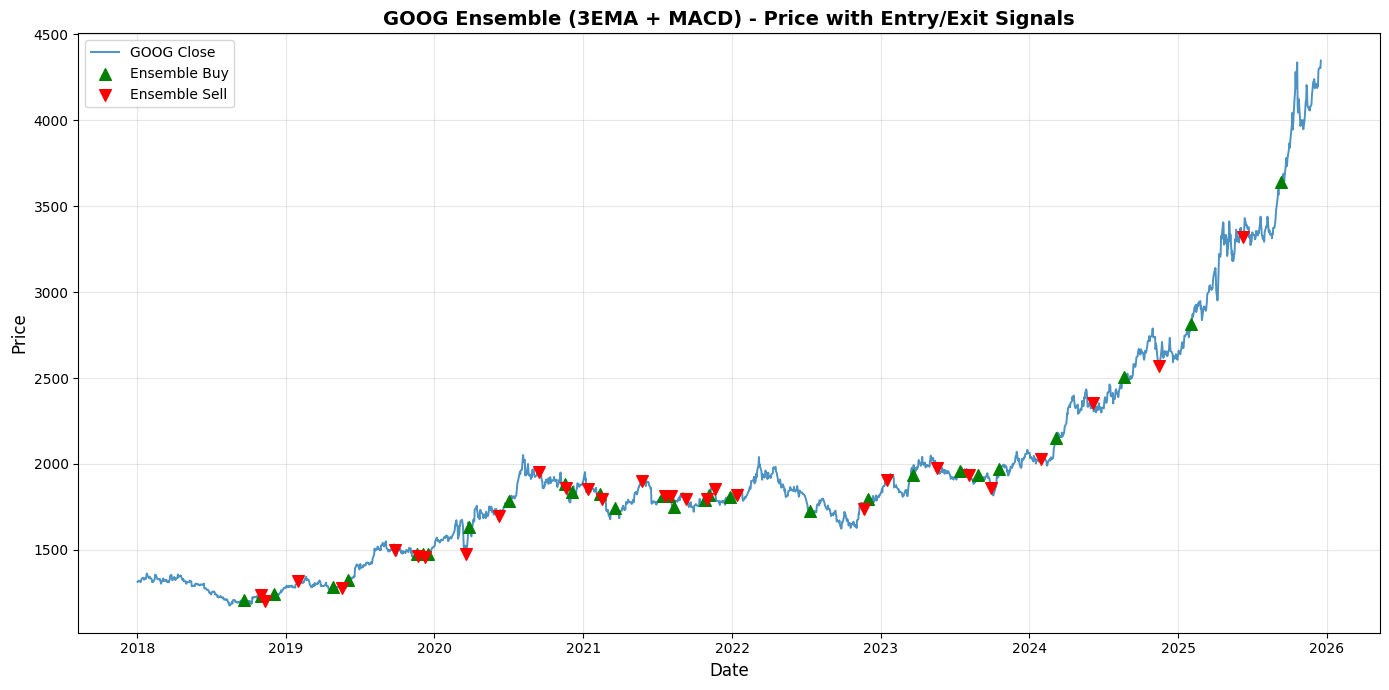

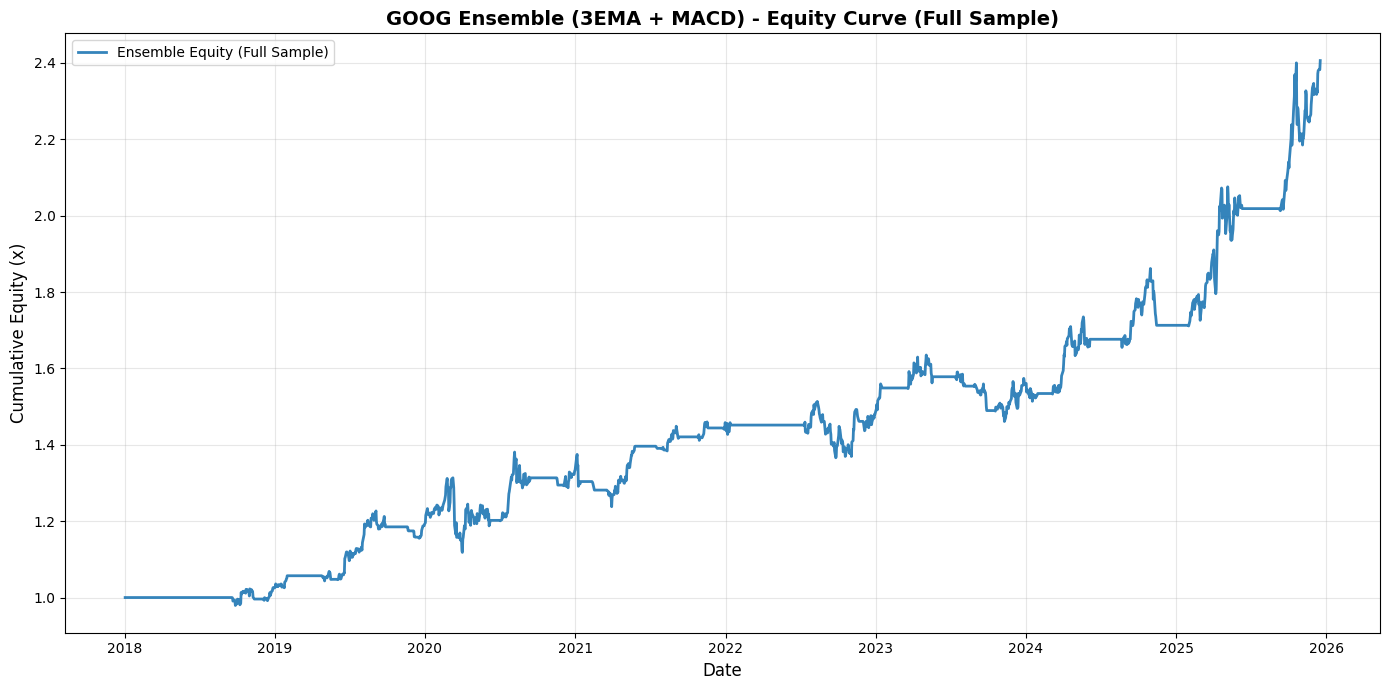

Trade-by-Trade Stats (Ensemble):
  Total trades     : 30
  Win rate         : 60.00%
  Avg win %        : 6.06%
  Avg loss %       : -1.29%
  Avg trade %      : 3.12%


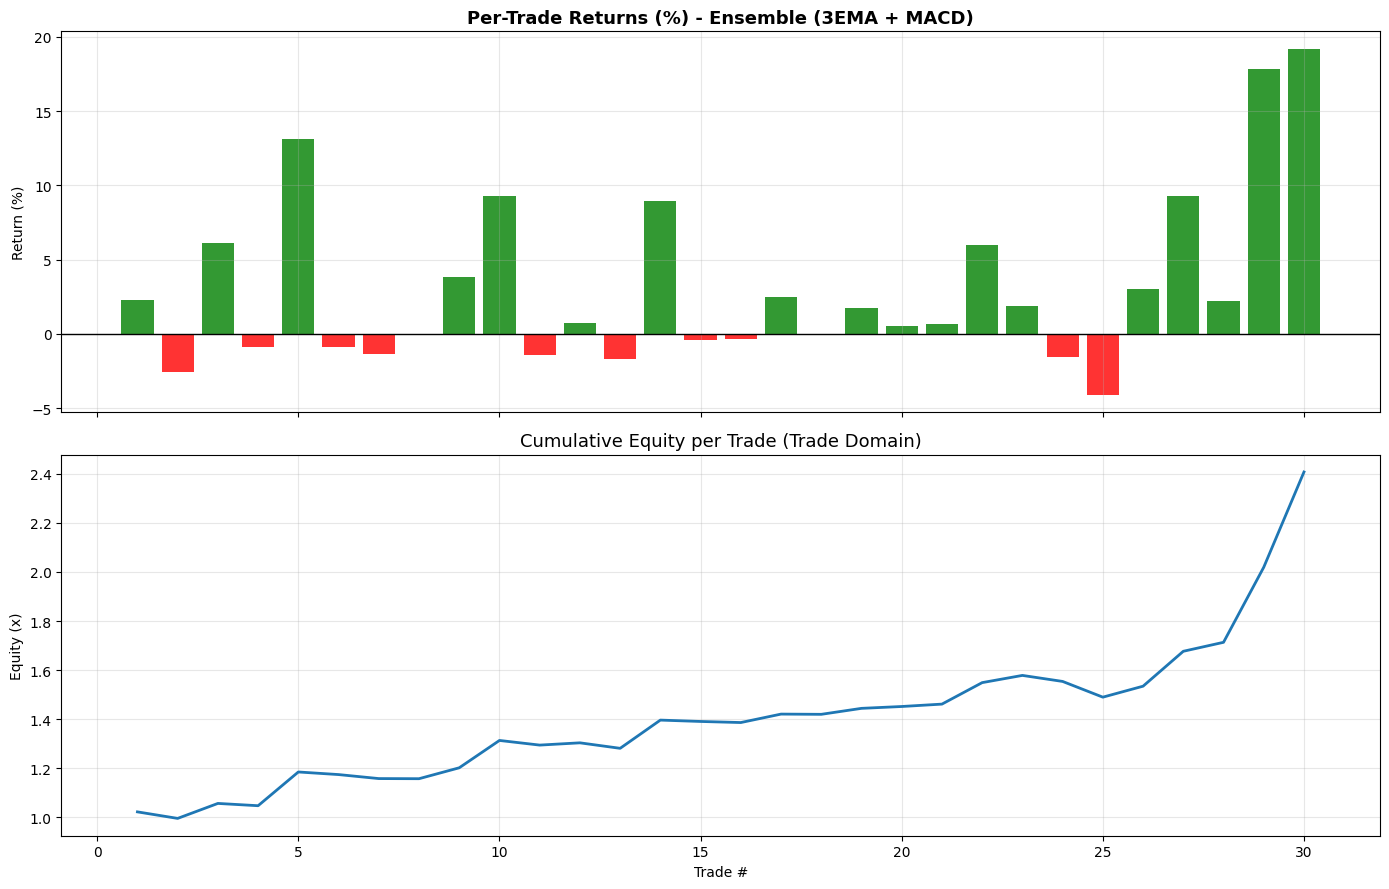

✅ Ensemble GOOG visualizations (price, equity, trade-by-trade) complete.


In [8]:
# ============================================================
# 6.5) VISUALS: PRICE, EQUITY CURVE, TRADE-BY-TRADE RETURNS
# ============================================================

import matplotlib.pyplot as plt

# Controlli base
if "signals_df" not in globals():
    raise ValueError("signals_df not found. Run the ensemble signal cells first.")

if "position_ensemble" not in signals_df.columns:
    raise ValueError("'position_ensemble' not found in signals_df. Build ensemble position first.")

price = signals_df["price"].astype(float)
pos = signals_df["position_ensemble"].fillna(0).astype(int)

# Rebuild entries / exits from position
entries_full = (pos.shift(1).fillna(0) == 0) & (pos == 1)
exits_full   = (pos.shift(1).fillna(0) == 1) & (pos == 0)

# Frequenza default se non definita
if "FREQ" not in globals():
    FREQ = "1D"

# Portfolio full-sample (riusa se esiste, altrimenti ricrea)
try:
    pf_full
except NameError:
    pf_full = vbt.Portfolio.from_signals(
        close=price,
        entries=entries_full,
        exits=exits_full,
        init_cash=100_000,
        fees=0.0005,
        slippage=0.0005,
        freq=FREQ
    )

# ============================================================
# 1) PREZZO + ENTRY / EXIT
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(price.index, price.values, label="GOOG Close", linewidth=1.4, alpha=0.8)

buy_idx = price.index[entries_full]
sell_idx = price.index[exits_full]

ax.scatter(buy_idx, price.loc[buy_idx].values,
           marker="^", s=70, label="Ensemble Buy", color="green", zorder=5)
ax.scatter(sell_idx, price.loc[sell_idx].values,
           marker="v", s=70, label="Ensemble Sell", color="red", zorder=5)

ax.set_title("GOOG Ensemble (3EMA + MACD) - Price with Entry/Exit Signals",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# ============================================================
# 2) EQUITY CURVE FULL SAMPLE
# ============================================================

eq_full = (1 + pf_full.returns()).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(eq_full.index, eq_full.values, linewidth=2, alpha=0.9, label="Ensemble Equity (Full Sample)")

ax.set_title("GOOG Ensemble (3EMA + MACD) - Equity Curve (Full Sample)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Cumulative Equity (x)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# ============================================================
# 3) TRADE-BY-TRADE RETURNS + EQUITY PER TRADE
# ============================================================

trades = pf_full.trades

trade_returns = trades.returns.values if hasattr(trades.returns, "values") else np.asarray(trades.returns)
trade_returns = np.asarray(trade_returns).ravel()  # ensure 1D

if trade_returns.size == 0:
    print("No trades to plot for trade-by-trade analysis.")
else:
    winning_trades = trade_returns[trade_returns > 0]
    losing_trades = trade_returns[trade_returns < 0]

    total_trades = len(trade_returns)
    win_count = len(winning_trades)
    loss_count = len(losing_trades)
    win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0.0

    avg_win_pct = (winning_trades.mean() * 100) if len(winning_trades) > 0 else 0.0
    avg_loss_pct = (losing_trades.mean() * 100) if len(losing_trades) > 0 else 0.0
    avg_trade_pct = (trade_returns.mean() * 100) if len(trade_returns) > 0 else 0.0

    # Cumulative equity per trade (starting from 1)
    equity_per_trade = (1 + trade_returns).cumprod()

    print("Trade-by-Trade Stats (Ensemble):")
    print(f"  Total trades     : {total_trades}")
    print(f"  Win rate         : {win_rate:.2f}%")
    print(f"  Avg win %        : {avg_win_pct:.2f}%")
    print(f"  Avg loss %       : {avg_loss_pct:.2f}%")
    print(f"  Avg trade %      : {avg_trade_pct:.2f}%")

    x = np.arange(1, total_trades + 1)

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    # Bar dei returns trade-by-trade
    colors = ["green" if r > 0 else "red" for r in trade_returns]
    axes[0].bar(x, trade_returns * 100, color=colors, alpha=0.8)
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("Per-Trade Returns (%) - Ensemble (3EMA + MACD)", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Return (%)")
    axes[0].grid(True, alpha=0.3)

    # Equity cumulata per trade
    axes[1].plot(x, equity_per_trade, linewidth=2)
    axes[1].set_title("Cumulative Equity per Trade (Trade Domain)", fontsize=13)
    axes[1].set_xlabel("Trade #")
    axes[1].set_ylabel("Equity (x)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("✅ Ensemble GOOG visualizations (price, equity, trade-by-trade) complete.")


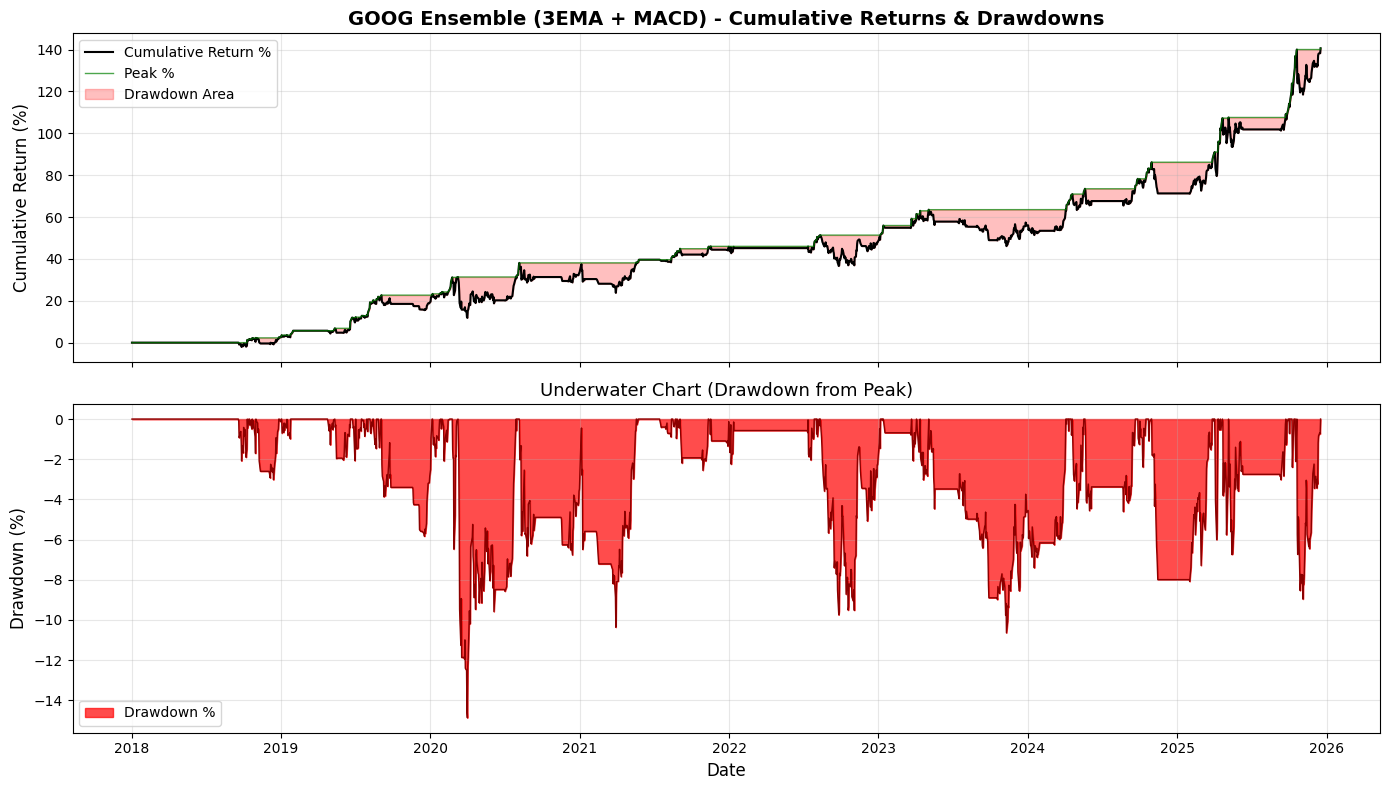

✅ Drawdown analysis (equity + underwater) complete for Ensemble GOOG.


In [9]:
# ============================================================
# 6.5.2) DRAWDOWNS: CUMULATIVE RETURNS + UNDERWATER CHART
# ============================================================

import matplotlib.pyplot as plt

# Controlli base
if "signals_df" not in globals():
    raise ValueError("signals_df not found. Run the ensemble signal cells first.")

if "position_ensemble" not in signals_df.columns:
    raise ValueError("'position_ensemble' not found in signals_df. Build ensemble position first.")

price = signals_df["price"].astype(float)
pos = signals_df["position_ensemble"].fillna(0).astype(int)

# Ricostruisci entries / exits (0 -> 1 = entry, 1 -> 0 = exit)
entries_full = (pos.shift(1).fillna(0) == 0) & (pos == 1)
exits_full   = (pos.shift(1).fillna(0) == 1) & (pos == 0)

# Frequenza default se non definita
if "FREQ" not in globals():
    FREQ = "1D"

# Usa pf_full se già esiste, altrimenti crealo
try:
    pf_dd = pf_full
except NameError:
    pf_dd = vbt.Portfolio.from_signals(
        close=price,
        entries=entries_full,
        exits=exits_full,
        init_cash=100_000,
        fees=0.0005,
        slippage=0.0005,
        freq=FREQ
    )

# Serie di rendimenti
ret = pf_dd.returns()

if ret.isna().all():
    print("⚠️ Not enough data to compute returns/drawdowns.")
else:
    # Equity, peak, drawdown
    eq = (1 + ret).cumprod()
    peak = eq.cummax()
    dd = (eq - peak) / peak  # valori negativi (drawdown)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # === 1) Cumulative Returns & Drawdown Area ===
    ax1.plot(eq.index, (eq - 1) * 100,
             color='black', linewidth=1.5, label='Cumulative Return %')
    ax1.plot(peak.index, (peak - 1) * 100,
             color='green', linewidth=1.0, alpha=0.7, label='Peak %')

    ax1.fill_between(
        eq.index,
        (eq - 1) * 100,
        (peak - 1) * 100,
        color='red',
        alpha=0.25,
        label='Drawdown Area'
    )

    ax1.set_title("GOOG Ensemble (3EMA + MACD) - Cumulative Returns & Drawdowns",
                  fontsize=14, fontweight='bold')
    ax1.set_ylabel("Cumulative Return (%)", fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # === 2) Underwater Chart (Drawdown %) ===
    ax2.fill_between(dd.index, dd * 100, 0,
                     color='red', alpha=0.7, label='Drawdown %')
    ax2.plot(dd.index, dd * 100,
             color='darkred', linewidth=1)

    ax2.set_title("Underwater Chart (Drawdown from Peak)", fontsize=13)
    ax2.set_xlabel("Date", fontsize=12)
    ax2.set_ylabel("Drawdown (%)", fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print("✅ Drawdown analysis (equity + underwater) complete for Ensemble GOOG.")


In [10]:
# ============================================================
# 6.5.3) METRICS SUMMARY: FULL vs TRAIN vs VAL (CORRECTED PARAMS)
# ============================================================

import pandas as pd
import numpy as np
import vectorbt as vbt

# --- 1. CONFIGURAZIONE (Match Exact User Settings) ---
SPLIT_DATE = '2022-10-04'
INIT_CASH  = 100_000
FEES       = 0.0005        # 0.05%
SLIPPAGE   = 0.0005        # 0.05%
SL_STOP    = None          # <--- CORREZIONE: Nessun Stop Loss (come nel tuo codice originale)

# --- 2. LOGICA ENSEMBLE (Entry B + Exit Veto) ---
def build_ensemble_position(signal_3ema, signal_macd, initial_position=0):
    s1 = signal_3ema.fillna(0).astype(int).values
    s2 = signal_macd.fillna(0).astype(int).values
    pos = initial_position
    positions = []

    for sig1, sig2 in zip(s1, s2):
        # ENTRY LOGIC (when flat)
        if pos == 0:
            # Conflitto: 1 vs -1 → NO
            if (sig1 == 1 and sig2 == -1) or (sig1 == -1 and sig2 == 1):
                pos = 0
            # Entry Permissiva: Basta un 1 (se l'altro non è -1)
            elif (sig1 == 1 and sig2 in (0, 1)) or (sig2 == 1 and sig1 in (0, 1)):
                pos = 1
            else:
                pos = 0
        # EXIT LOGIC (when long)
        else:
            # Exit Severa (Veto): Basta un -1 per uscire
            if sig1 == -1 or sig2 == -1:
                pos = 0
            else:
                pos = 1 
        positions.append(pos)

    return pd.Series(positions, index=signal_3ema.index, name="position_ensemble")

# --- 3. COSTRUZIONE PORTFOLIO ---
if "signals_df" not in globals():
    raise ValueError("signals_df missing.")

# Ricalcolo posizione per certezza
signals_df["position_ensemble"] = build_ensemble_position(
    signals_df["signal_3ema"], 
    signals_df["signal_macd"]
)

price = signals_df["price"].astype(float)
pos = signals_df["position_ensemble"].fillna(0).astype(int)

# Entry/Exit logica
entries = (pos.shift(1).fillna(0) == 0) & (pos == 1)
exits   = (pos.shift(1).fillna(0) == 1) & (pos == 0)

# --- 4. CREAZIONE SLICES (Full, Train, Val) ---
# Usiamo gli STESSI parametri per tutti e 3 per coerenza assoluta

if not isinstance(price.index, pd.DatetimeIndex):
    price.index = pd.to_datetime(price.index)

split_ts = pd.Timestamp(SPLIT_DATE)
mask_train = price.index < split_ts
mask_val   = price.index >= split_ts

# FULL SAMPLE
pf_full = vbt.Portfolio.from_signals(
    close=price, entries=entries, exits=exits, freq="1D", 
    init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, sl_stop=SL_STOP
)

# TRAIN SAMPLE
pf_train = vbt.Portfolio.from_signals(
    close=price[mask_train], entries=entries[mask_train], exits=exits[mask_train], freq="1D", 
    init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, sl_stop=SL_STOP
)

# VALIDATION SAMPLE
pf_val = vbt.Portfolio.from_signals(
    close=price[mask_val], entries=entries[mask_val], exits=exits[mask_val], freq="1D", 
    init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, sl_stop=SL_STOP
)

# --- 5. REPORTING ---
def get_metrics(pf_slice):
    if pf_slice.trades.count() == 0:
        return {k: 0 for k in ["Total Return", "Sharpe", "Max DD", "Win Rate"]}
    
    trade_rets = pf_slice.trades.returns.values if hasattr(pf_slice.trades.returns, "values") else np.array(pf_slice.trades.returns)
    trade_rets = np.asarray(trade_rets).ravel()
    
    wins = trade_rets[trade_rets > 0]
    losses = trade_rets[trade_rets < 0]
    n_trades = len(trade_rets)
    
    return {
        "Total Return": float(pf_slice.total_return()),
        "Annual Return": float(pf_slice.annualized_return()),
        "Volatility": float(pf_slice.annualized_volatility()),
        "Sharpe": float(pf_slice.sharpe_ratio()),
        "Sortino": float(pf_slice.sortino_ratio()),
        "Max Drawdown": float(pf_slice.max_drawdown()),
        "Calmar": float(pf_slice.calmar_ratio()),
        "Win Rate": (len(wins)/n_trades * 100) if n_trades > 0 else 0.0,
        "Trades": n_trades,
        "Profit Factor": (wins.sum() / abs(losses.sum())) if abs(losses.sum()) > 0 else np.inf,
        "Expectancy": trade_rets.mean() if n_trades > 0 else 0.0
    }

m_full  = get_metrics(pf_full)
m_train = get_metrics(pf_train)
m_val   = get_metrics(pf_val)

metrics_df = pd.DataFrame({
    "Metric": [
        "Total Return", "Annual Return", "Annual Volatility", 
        "Sharpe Ratio", "Sortino Ratio", "Max Drawdown", "Calmar Ratio",
        "Win Rate", "Total Trades", "Profit Factor", "Expectancy"
    ],
    "Full Sample": [
        f"{m_full['Total Return']*100:.2f} %", f"{m_full['Annual Return']*100:.2f} %", f"{m_full['Volatility']*100:.2f} %",
        f"{m_full['Sharpe']:.3f}", f"{m_full['Sortino']:.3f}", f"{m_full['Max Drawdown']*100:.2f} %", f"{m_full['Calmar']:.3f}",
        f"{m_full['Win Rate']:.2f} %", int(m_full['Trades']), f"{m_full['Profit Factor']:.3f}", f"{m_full['Expectancy']*100:.3f} %"
    ],
    "Train (In-Sample)": [
        f"{m_train['Total Return']*100:.2f} %", f"{m_train['Annual Return']*100:.2f} %", f"{m_train['Volatility']*100:.2f} %",
        f"{m_train['Sharpe']:.3f}", f"{m_train['Sortino']:.3f}", f"{m_train['Max Drawdown']*100:.2f} %", f"{m_train['Calmar']:.3f}",
        f"{m_train['Win Rate']:.2f} %", int(m_train['Trades']), f"{m_train['Profit Factor']:.3f}", f"{m_train['Expectancy']*100:.3f} %"
    ],
    "Val (Out-of-Sample)": [
        f"{m_val['Total Return']*100:.2f} %", f"{m_val['Annual Return']*100:.2f} %", f"{m_val['Volatility']*100:.2f} %",
        f"{m_val['Sharpe']:.3f}", f"{m_val['Sortino']:.3f}", f"{m_val['Max Drawdown']*100:.2f} %", f"{m_val['Calmar']:.3f}",
        f"{m_val['Win Rate']:.2f} %", int(m_val['Trades']), f"{m_val['Profit Factor']:.3f}", f"{m_val['Expectancy']*100:.3f} %"
    ]
})

print("="*80)
print(f"ENSEMBLE METRICS (Entry B + Exit Veto)")
print(f"Settings: Fees={FEES}, Slippage={SLIPPAGE}, StopLoss={SL_STOP}")
print("="*80)
display(metrics_df)

ENSEMBLE METRICS (Entry B + Exit Veto)
Settings: Fees=0.0005, Slippage=0.0005, StopLoss=None


,Metric,Full Sample,Train (In-Sample),Val (Out-of-Sample)
0,Total Return,140.60 %,42.46 %,64.65 %
1,Annual Return,17.35 %,11.40 %,25.30 %
2,Annual Volatility,14.42 %,12.89 %,15.87 %
3,Sharpe Ratio,1.182,0.903,1.501
4,Sortino Ratio,1.721,1.296,2.196
5,Max Drawdown,-14.87 %,-14.87 %,-10.64 %
6,Calmar Ratio,1.167,0.767,2.377
7,Win Rate,60.00 %,47.62 %,77.78 %
8,Total Trades,30,21,9
9,Profit Factor,7.072,4.222,10.459


In [11]:
# ============================================================
# 7) SAVE ENSEMBLE RESULTS FOR GOOG
# ============================================================

from pathlib import Path
import json

base_ensemble = Path("data") / "ensemble" / "xauusd"
base_ensemble.mkdir(parents=True, exist_ok=True)

best_params_ensemble_xauusd = {
    "entry_logic": "Option B (enter on (1,1) or (1,0)/(0,1); block 1/-1 conflicts)",
    "exit_logic": "Veto (-1 from either) OR both 0",
    "source_parameters": {
        "3EMA_params": "best_params_3ema_xauusd.json",
        "MACD_params": "best_params_macd_xauusd.json",
    }
}

best_metrics_ensemble_xauusd = {
    "total_return": float(ensemble_results.get("total_return", 0.0)),
    "annual_return": float(ensemble_results.get("annual_return", 0.0)),
    "volatility": float(ensemble_results.get("volatility", 0.0)),
    "sharpe_ratio": float(ensemble_results.get("sharpe_ratio", 0.0)),
    "max_drawdown": float(ensemble_results.get("max_drawdown", 0.0)),
    "calmar_ratio": float(ensemble_results.get("calmar_ratio", 0.0)),
    "win_rate": float(ensemble_results.get("win_rate", 0.0)),
    "total_trades": int(ensemble_results.get("total_trades", 0)),
    "profit_factor": float(ensemble_results.get("profit_factor", 0.0)),
    "expectancy": float(ensemble_results.get("expectancy", 0.0)),
}

params_path = base_ensemble / "best_params_ensemble_xauusd.json"
metrics_path = base_ensemble / "best_metrics_ensemble_xauusd.json"

with params_path.open("w") as f:
    json.dump(best_params_ensemble_xauusd, f, indent=4)

with metrics_path.open("w") as f:
    json.dump(best_metrics_ensemble_xauusd, f, indent=4)

print("Saved ensemble params:", params_path.resolve())
print("Saved ensemble metrics:", metrics_path.resolve())
best_metrics_ensemble_xauusd


Saved ensemble params: C:\Users\clanf\OneDrive\Desktop\algo trading\FTMO_Challenge\data\ensemble\xauusd\best_params_ensemble_xauusd.json
Saved ensemble metrics: C:\Users\clanf\OneDrive\Desktop\algo trading\FTMO_Challenge\data\ensemble\xauusd\best_metrics_ensemble_xauusd.json


{'total_return': 1.4060217551304492,
 'annual_return': 0.1734995933508756,
 'volatility': 0.14415864717346444,
 'sharpe_ratio': 1.1822249280282293,
 'max_drawdown': -0.14871103605808822,
 'calmar_ratio': 1.1666894263523568,
 'win_rate': 60.0,
 'total_trades': 30,
 'profit_factor': 7.071648032387675,
 'expectancy': 0.031215903970221573}

In [12]:
import os
import pandas as pd

# ============================================================
# 6) EXPORT DATA FOR ALLOCATION TEMPLATE (FTMO DATASET)
# ============================================================

# --- CONFIGURAZIONE ---
# IMPORTANTE: Cambia questo ticker ogni volta che cambi asset nel notebook!
CURRENT_TICKER = "GC=F" 
OUTPUT_FOLDER = "ftmo_dataset"

# 1. Creazione Cartella di Destinazione
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)
    print(f"📁 Cartella '{OUTPUT_FOLDER}' creata con successo.")

# 2. Costruzione del DataFrame di Export
# Usiamo l'indice temporale di signals_df come base
export_df = pd.DataFrame(index=signals_df.index)

# A. PREZZO (Fondamentale per il calcolo dei lotti/sizing nel template)
export_df[f'{CURRENT_TICKER}_Close'] = signals_df['price']

# B. RENDIMENTI (Serve per calcolare la curva dei profitti)
export_df[f'{CURRENT_TICKER}_Return'] = signals_df['price'].pct_change()

# C. POSIZIONE (Il risultato della tua logica Ensemble Stateful)
# Assicuriamoci che siano interi (0 o 1)
export_df[f'{CURRENT_TICKER}_Position'] = signals_df['position_ensemble'].astype(int)

# D. RSI (Opzionale: Se vuoi che il template usi l'RSI per il ranking, 
# possiamo lasciarlo calcolare al template stesso usando la colonna Close, 
# oppure pre-calcolarlo qui se vuoi un RSI custom. Per ora lasciamo fare al template).

# 3. Pulizia Dati
# Rimuoviamo la prima riga che avrà NaN a causa del pct_change()
export_df.dropna(inplace=True)

# 4. Salvataggio su CSV
filename = f"{OUTPUT_FOLDER}/{CURRENT_TICKER}_returns.csv"
export_df.to_csv(filename)

print("="*60)
print(f"✅ EXPORT COMPLETATO: {CURRENT_TICKER}")
print(f"📍 File salvato in: {filename}")
print(f"📊 Dimensioni: {len(export_df)} giorni di trading")
print("-" * 60)
print("Colonne esportate:")
print(list(export_df.columns))
print("\nAnteprima ultime 5 righe (Verifica che Position sia 0 o 1):")
print(export_df.tail())
print("="*60)

✅ EXPORT COMPLETATO: GC=F
📍 File salvato in: ftmo_dataset/GC=F_returns.csv
📊 Dimensioni: 2002 giorni di trading
------------------------------------------------------------
Colonne esportate:
['GC=F_Close', 'GC=F_Return', 'GC=F_Position']

Anteprima ultime 5 righe (Verifica che Position sia 0 o 1):
             GC=F_Close  GC=F_Return  GC=F_Position
Date                                               
2025-12-11  4285.500000     0.021233              1
2025-12-12  4300.100098     0.003407              1
2025-12-15  4306.700195     0.001535              1
2025-12-16  4304.500000    -0.000511              1
2025-12-17  4347.299805     0.009943              1
